# Testing bessel function expansion code

### 1) Input $f(r) = j_0(k_{0,0}*r) + 2j_1(k_{1,0}*r) + j_1(k_{1,1}*r) $
### answer should be $a_{0,0} = 1, a_{1,0} = 2, a_{1,1} = 1, a_{l,n}$ for the rest

Spherical bessel functions $j_l$ are defined by the l number, they osciallate with a frequency set by $k_{l,n}$, so for each l we have n different k values. The maximum n is set to be the number of radial bins since this is the maximum number of discrete k values we can extract. $K_{l,n}$ is set to the zeros of the bessel function (l) but scaled by rmax so that within [0, rmax], these spherical bessel functions form an orthogonal basis.


In [1]:
import sys
sys.path.append('/home/joshua/PhD_year_1/jaxsp/Adding_stellar_masses')

from scipy.special import spherical_jn

import Boris_SBT_code as BSBT

import numpy as np

import jax

import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

l = [0, 1]
L = max(l) + 1

rmax = 440
rmin = 0.02
no_radius_bins = 1000  #change this, more bins means better precision

k_list = []
cln_list = []
for ell in range(L):
    k_nodes, _cln = BSBT.constructGridAndNorms(rmax, no_radius_bins, ell)
    k_list.append(np.asarray(k_nodes, dtype=np.float64)) 
    cln_list.append(np.asarray(_cln, dtype=np.float64))

# For each value of ell, computes n k nodes and n cl normalization constants.

kln_nodes_by_ell = np.asarray(np.stack(k_list, axis=0)) 
cln_norms_by_ell = np.asarray(np.stack(cln_list, axis=0))  

print("kln_nodes_by_ell shape:", kln_nodes_by_ell.shape)
print("cln_norms_by_ell shape:", cln_norms_by_ell.shape) #(ell, n)



kln_nodes_by_ell shape: (2, 1000)
cln_norms_by_ell shape: (2, 1000)


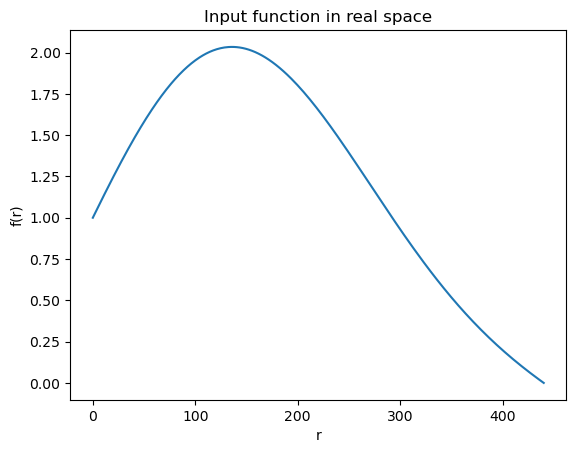

In [2]:
lm_pairs = np.array([(0, 0), (1, 0), (1, 1), (1, -1)])

lm_l = lm_pairs[:, 0]
lm_m = lm_pairs[:, 1]

L = int(lm_l.max()) + 1

r_j = np.logspace(np.log10(rmin), np.log10(rmax), no_radius_bins)

# rho_lm_r shape: (Nr, L, 2*L-1)
rho_lm_r = np.zeros((no_radius_bins, L, 2*L - 1))

# l=0, m=0  -> index [:, 0, 0 + (L-1)] = [:, 0, 1]
k00 = kln_nodes_by_ell[0, 0]   # l = 0, n = 0
rho_lm_r[:, 0, 0 + (L-1)] = spherical_jn(0, k00 * r_j)

# l=1, m=0  -> index [:, 1, 0 + (L-1)] = [:, 1, 1]
k10 = kln_nodes_by_ell[1, 0]   # l = 1, n = 0
rho_lm_r[:, 1, 0 + (L-1)] = 2 * spherical_jn(1, k10 * r_j)

k11 = kln_nodes_by_ell[1, 1]   # l = 1, n = 1
rho_lm_r[:, 1, 0 + (L-1)] += spherical_jn(1, k11 * r_j)

# k0100 = kln_nodes_by_ell[0, 100]   # l = 0, n = 100
# rho_lm_r[:, 0, 0 + (L-1)] += 3 * spherical_jn(0, k0100 * r_j)

f_input = (spherical_jn(0, k00 * r_j) + 
    2 * spherical_jn(1, k10 * r_j) + 
    spherical_jn(1, k11 * r_j))
    # +3 * spherical_jn(0, k0100 * r_j))

plt.plot(r_j, f_input, label='input function')
plt.xlabel('r')
plt.ylabel('f(r)')
plt.title('Input function in real space')
plt.show()

f_l_kln_all = BSBT.forward_dsbt_all(
    rho_lm_r=rho_lm_r,
    r=r_j,
    lm_l=lm_l,
    lm_m=lm_m,
    L=L,
    kln_nodes_by_ell=kln_nodes_by_ell,
    chunk_size=16,
)




In [3]:
print(f_l_kln_all.shape) # (lm_pairs, n)

(4, 1000)


In [4]:
cln_for_lm = cln_norms_by_ell[lm_l, :]

normalised = f_l_kln_all * cln_for_lm

print(normalised[0,0]) # l = 0, n = 0, m = 0 
print(normalised[1,0]) # l = 1, n = 0, m = 0
print(normalised[1,1]) # l = 1, n = 1, m = 0 should be 1
print(normalised[0, 100])
print(normalised[0, :])

1.0000166928155452
2.000033385591131
1.0000167154614668
-0.0001304805715870595
[ 1.00001669e+00  1.32109578e-08 -2.97532412e-08  5.29184778e-08
 -8.28037054e-08  1.19347355e-07 -1.62754642e-07  2.12874382e-07
 -2.70059771e-07  3.34031227e-07 -4.05330042e-07  4.83509243e-07
 -5.69338610e-07  6.62165083e-07 -7.63027434e-07  8.71028009e-07
 -9.87515272e-07  1.11130867e-06 -1.24410725e-06  1.38440951e-06
 -1.53430619e-06  1.69193695e-06 -1.85982564e-06  2.03571549e-06
 -2.22260506e-06  2.41780388e-06 -2.62482714e-06  2.84051363e-06
 -3.06893750e-06  3.30643013e-06 -3.55766718e-06  3.81843639e-06
 -4.09405803e-06  4.37974027e-06 -4.68149147e-06  4.99390497e-06
 -5.32372110e-06  5.66488349e-06 -6.02490917e-06  6.39705778e-06
 -6.78966820e-06  7.19528273e-06 -7.62310801e-06  8.06493616e-06
 -8.53088828e-06  9.01197444e-06 -9.51927806e-06  1.00429964e-05
 -1.05952241e-05  1.11653157e-05 -1.17664267e-05  1.23870408e-05
 -1.30414264e-05  1.37171692e-05 -1.44297030e-05  1.51656904e-05
 -1.5941786

### Problem!! Since I have set $n_{max} = N_r$, we are going up to too high n which means we are getting large values for the large n coefficients!

### The normalisation constant $C_{ln} = \frac{\sqrt{2\pi}}{R^3j_{l+1}(z_{ln})^2}$, for large n, the zeros roughly grow as $z_{ln} \simeq n\pi$ and the $j_l$ scales as $|j_l(z)| \simeq 1/z$.
### $\therefore |j_{l+1}(z_{ln})| \simeq 1/(n\pi)$ and $C_{ln} \simeq \frac{(n\pi)^2}{R^3}$ meaning the normalisation constants scale as $n^2$ making large n coefficients bigger. 

### Also at large n, the bessel function frequency is very high meaning they oscillate rapidly and the integral becomes inaccurate. Therefore we must pick a smaller $n_{max}$ to use!

### For a log spacing in r, a sensible $n_{max}$ to use is $n_{max} \simeq \frac{Nr}{2\ln({r_{max}/r_{min}})}$.

### For the case of $N_r = 1000$ and $r_{max} = 10$, $r_{min} = 0.01$ gives $n_{max} \simeq \frac{N_r}{14} \simeq 70$

1.0000166928155452
-3.11659018388676e-05
-2.162892660490681


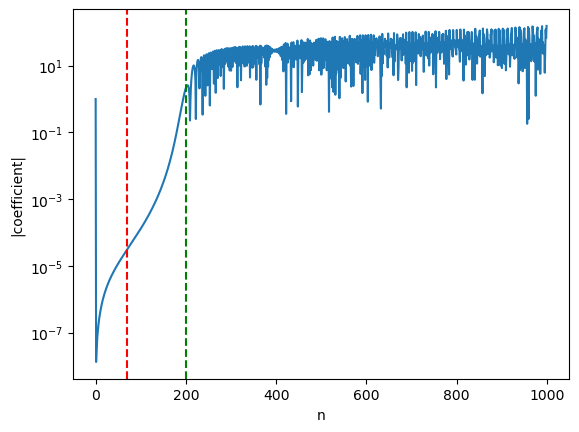

In [5]:

plt.semilogy(np.abs(normalised[0, :]))
plt.xlabel('n')
plt.ylabel('|coefficient|')
plt.axvline(x=70, color='r', linestyle='--')
plt.axvline(x = 200, color='g', linestyle='--')

print(normalised[0, 0]) # l = 0, n = 0, m = 0

print(normalised[0, 70]) # l = 0, n = 70
print(normalised[0, 200]) # l = 0, n = 200

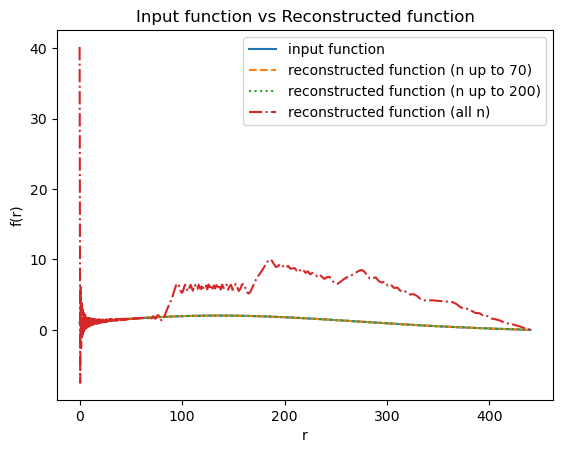

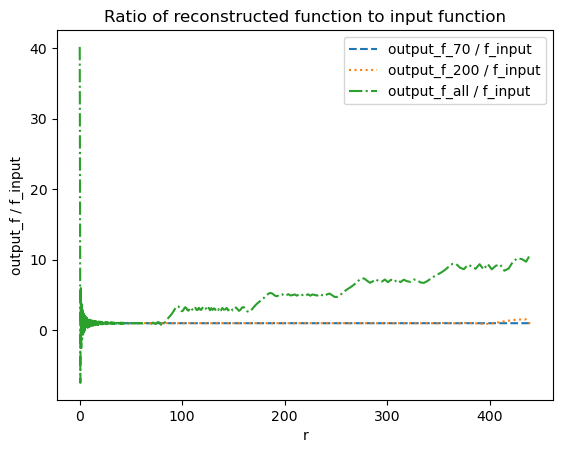

In [6]:
# reproduce starting function using sum of coefficients up to n = 70

output_f_70 = np.zeros_like(r_j)
output_f_200 = np.zeros_like(r_j)
output_f_all = np.zeros_like(r_j)

for idx, (l_val, m_val) in enumerate(lm_pairs):
    for n in range(70):
        k_ln = kln_nodes_by_ell[l_val, n]
        coeff = normalised[idx, n]
        output_f_70 += coeff * spherical_jn(l_val, k_ln * r_j)
        output_f_200 += coeff * spherical_jn(l_val, k_ln * r_j)
        output_f_all += coeff * spherical_jn(l_val, k_ln * r_j)
    
    for n in range(70, 200):
        k_ln = kln_nodes_by_ell[l_val, n]
        coeff = normalised[idx, n]
        output_f_200 += coeff * spherical_jn(l_val, k_ln * r_j)
        output_f_all += coeff * spherical_jn(l_val, k_ln * r_j)

    for n in range(200, normalised.shape[1]):
        k_ln = kln_nodes_by_ell[l_val, n]
        coeff = normalised[idx, n]
        output_f_all += coeff * spherical_jn(l_val, k_ln * r_j)


plt.plot(r_j, f_input, label='input function')
plt.plot(r_j, output_f_70, label='reconstructed function (n up to 70)', linestyle='--')
plt.plot(r_j, output_f_200, label='reconstructed function (n up to 200)', linestyle=':')
plt.plot(r_j, output_f_all, label='reconstructed function (all n)', linestyle='-.')
plt.xlabel('r')
plt.ylabel('f(r)')
plt.title('Input function vs Reconstructed function')
plt.legend()
plt.show()

plt.plot(r_j, output_f_70 / f_input, label='output_f_70 / f_input', linestyle='--')
plt.plot(r_j, output_f_200 / f_input, label='output_f_200 / f_input', linestyle=':')
plt.plot(r_j, output_f_all / f_input, label='output_f_all / f_input', linestyle='-.')
plt.xlabel('r')
plt.ylabel('output_f / f_input')
plt.title('Ratio of reconstructed function to input function')
plt.legend()
plt.show()

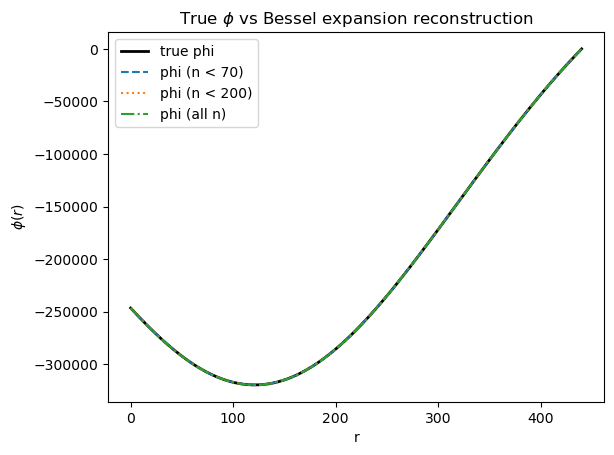

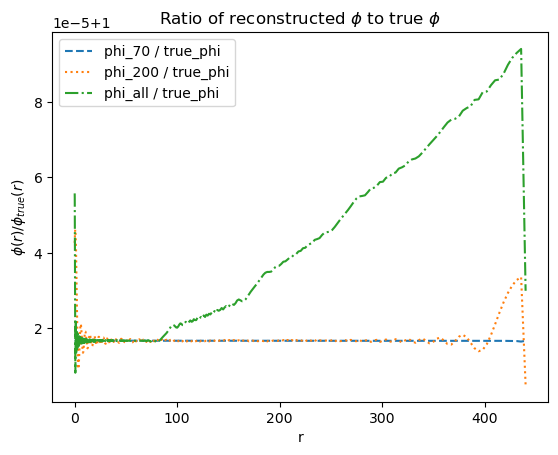

In [7]:

# True phi: solve nabla^2[phi] = 4*pi*G*rho with G=1.
# Since nabla^2[j_l(k*r)] = -k^2 * j_l(k*r), the particular solution is phi = -4*pi*G/k^2 * rho,
# applied mode by mode. The boundary condition phi(rmax)=0 is automatically satisfied because
# k_ln are chosen so j_l(k_ln * rmax) = 0.
G = 1

true_phi = -4 * np.pi * G * (
    spherical_jn(0, k00 * r_j) / k00**2 +
    2 * spherical_jn(1, k10 * r_j) / k10**2 + 
    spherical_jn(1, k11 * r_j) / k11**2 
    #3 * spherical_jn(0, k0100 * r_j) / k0100**2
)

# Reconstruct phi from the Bessel expansion coefficients:
# phi(r) = sum_n [ -4*pi*G * normalised[idx,n] / k_ln^2 ] * j_l(k_ln * r)
phi_70  = np.zeros_like(r_j)
phi_200 = np.zeros_like(r_j)
phi_all = np.zeros_like(r_j)

for idx, (l_val, m_val) in enumerate(lm_pairs):
    for n in range(normalised.shape[1]):
        k_ln = kln_nodes_by_ell[l_val, n]
        phi_coeff = -4 * np.pi * G * normalised[idx, n] / k_ln**2
        if n < 70:
            phi_70  += phi_coeff * spherical_jn(l_val, k_ln * r_j)
        if n < 200:
            phi_200 += phi_coeff * spherical_jn(l_val, k_ln * r_j)
        phi_all += phi_coeff * spherical_jn(l_val, k_ln * r_j)

plt.plot(r_j, true_phi, label='true phi', linewidth=2, color='black')
plt.plot(r_j, phi_70,   label='phi (n < 70)',  linestyle='--')
plt.plot(r_j, phi_200,  label='phi (n < 200)', linestyle=':')
plt.plot(r_j, phi_all,  label='phi (all n)',   linestyle='-.')
plt.xlabel('r')
plt.ylabel(r'$\phi(r)$')
plt.title(r'True $\phi$ vs Bessel expansion reconstruction')
plt.legend()
plt.show()

plt.plot(r_j, phi_70 / true_phi, label='phi_70 / true_phi', linestyle='--')
plt.plot(r_j, phi_200 / true_phi, label='phi_200 / true_phi', linestyle=':')
plt.plot(r_j, phi_all / true_phi, label='phi_all / true_phi', linestyle='-.')
plt.xlabel('r')
plt.ylabel(r'$\phi(r) / \phi_{true}(r)$')
plt.title(r'Ratio of reconstructed $\phi$ to true $\phi$')
plt.legend()
plt.show()

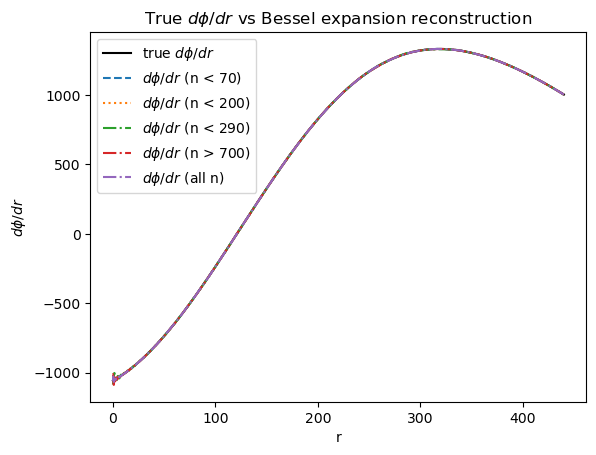

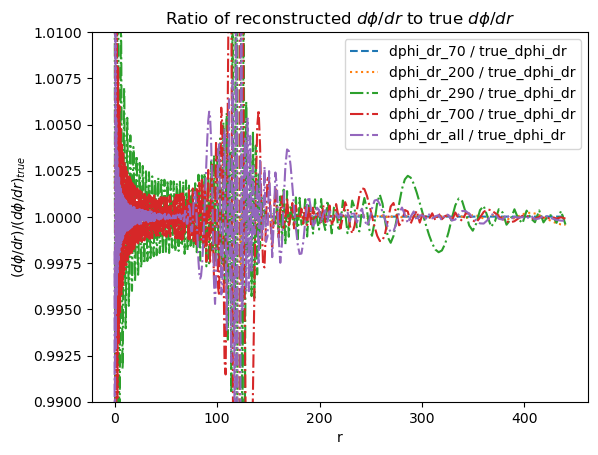

In [8]:

# True dphi/dr: differentiate phi analytically.
# d/dr [ j_l(k*r) ] = k * j_l'(k*r)  where j_l'(x) = dj_l/dx = spherical_jn(l, x, derivative=True)
# So dphi/dr = -4*pi*G * ( k00 * j_0'(k00*r) / k00^2  +  2 * k10 * j_1'(k10*r) / k10^2 )
#            = -4*pi*G * ( j_0'(k00*r) / k00  +  2 * j_1'(k10*r) / k10 )

true_dphi_dr = -4 * np.pi * G * (
    spherical_jn(0, k00 * r_j, derivative=True) / k00 
    + 2 * spherical_jn(1, k10 * r_j, derivative=True) / k10
    + spherical_jn(1, k11 * r_j, derivative=True) / k11
   # + 3 * spherical_jn(0, k0100 * r_j, derivative=True) / k0100
)

# Reconstruct dphi/dr from Bessel expansion:
# d/dr [ phi_nlm * j_l(k_ln*r) ] = phi_nlm * k_ln * j_l'(k_ln*r)
#   = ( -4*pi*G * normalised[idx,n] / k_ln^2 ) * k_ln * j_l'(k_ln*r)
#   = ( -4*pi*G * normalised[idx,n] / k_ln ) * j_l'(k_ln*r)
dphi_dr_70  = np.zeros_like(r_j)
dphi_dr_200 = np.zeros_like(r_j)
dphi_dr_290 = np.zeros_like(r_j)
dphi_dr_700 = np.zeros_like(r_j)
dphi_dr_all = np.zeros_like(r_j)

for idx, (l_val, m_val) in enumerate(lm_pairs):
    for n in range(normalised.shape[1]):
        k_ln = kln_nodes_by_ell[l_val, n]
        dphi_coeff = -4 * np.pi * G * normalised[idx, n] / k_ln
        dj = spherical_jn(l_val, k_ln * r_j, derivative=True)
        if n < 70:
            dphi_dr_70  += dphi_coeff * dj
        if n < 200:
            dphi_dr_200 += dphi_coeff * dj
        if n < 290:
            dphi_dr_290 += dphi_coeff * dj
        if n < 700:
            dphi_dr_700 += dphi_coeff * dj
        dphi_dr_all += dphi_coeff * dj

plt.plot(r_j, true_dphi_dr, label=r'true $d\phi/dr$', color='black')
plt.plot(r_j, dphi_dr_70,   label=r'$d\phi/dr$ (n < 70)',  linestyle='--')
plt.plot(r_j, dphi_dr_200,  label=r'$d\phi/dr$ (n < 200)', linestyle=':')
plt.plot(r_j, dphi_dr_290,  label=r'$d\phi/dr$ (n < 290)', linestyle='-.')
plt.plot(r_j, dphi_dr_700,  label=r'$d\phi/dr$ (n > 700)', linestyle='-.')
plt.plot(r_j, dphi_dr_all,  label=r'$d\phi/dr$ (all n)',   linestyle='-.')
plt.xlabel('r')
plt.ylabel(r'$d\phi/dr$')
plt.title(r'True $d\phi/dr$ vs Bessel expansion reconstruction')
plt.legend()
plt.show()

plt.plot(r_j, dphi_dr_70 / true_dphi_dr, label='dphi_dr_70 / true_dphi_dr', linestyle='--')
plt.plot(r_j, dphi_dr_200 / true_dphi_dr, label='dphi_dr_200 / true_dphi_dr', linestyle=':')
plt.plot(r_j, dphi_dr_290 / true_dphi_dr, label='dphi_dr_290 / true_dphi_dr', linestyle='-.')
plt.plot(r_j, dphi_dr_700 / true_dphi_dr, label='dphi_dr_700 / true_dphi_dr', linestyle='-.')
plt.plot(r_j, dphi_dr_all / true_dphi_dr, label='dphi_dr_all / true_dphi_dr', linestyle='-.')
plt.xlabel('r')
plt.ylabel(r'$(d\phi/dr) / (d\phi/dr)_{true}$')
plt.ylim([0.99, 1.01])
plt.title(r'Ratio of reconstructed $d\phi/dr$ to true $d\phi/dr$')
plt.legend()
plt.show()  

### Something to do with when dphi/dr is at 0?

### $r_{spike} \simeq \frac{2N_rr_{max}}{N*\ln({r_{max}/r_{min}})}$
### $\therefore r_{spike} \simeq 2.9$
### Need $N < \frac{2N_r}{ln({r_{max}/r_{min}})} \simeq 290$


### Gibbs ringing $N_{min} \simeq \frac{N_r}{2*\ln({r_{max}/r_{min}})}$. In reality its much higher than this as our density field is highly oscillatory.

### $N_{max} \simeq \frac{2*N_r}{\ln({r_{max}/r_{min}})}$, sets the spike to be at $r_{max}$. We can set this to be even higher given we assume our particle wont go anywhere near $r_{max}$. 

### For our simulation, $r_{spike} \simeq \frac{2 * 1000 * 418}{N * ln(418/0.02)}$
### $\therefore$ if $N = 1000$, $r_{spike} = 84$ Kpc, should be no where near our particle position if we're starting it off at 0.19 Kpc!! 

### Therefore we will get this spike of error but it will be much further out than the particle

### Also need to consider the fact we want to be able to resolve granules of small sizes, therefore should maybe increase number of r bins and use $n_{max}$ = number of r bins

# Different contributions: 

## Want N small: Spike, $n^2$ Noise at small r, time
## Want N large: Ability to resolve small granules, our $\rho$ is highly oscillatory

In [9]:
# write a functions which works as a function of n_max, so we can easily plot the convergence as a function of n_max.
N_n = normalised.shape[1]


per_n_contrib = np.zeros((N_n, len(r_j)))

for idx, (l_val, m_val) in enumerate(lm_pairs):
    k_lns = kln_nodes_by_ell[l_val, :]                          # (N_n,)
    dphi_coeffs = -4 * np.pi * G * normalised[idx, :] / k_lns  # (N_n,)
    for n in range(N_n):
        per_n_contrib[n] += dphi_coeffs[n] * spherical_jn(l_val, k_lns[n] * r_j, derivative=True)


cumsum = np.cumsum(per_n_contrib, axis=0)  # (N_n, Nr)

dphi_dr_conv = {nmax: cumsum[nmax - 1] for nmax in range(1, N_n + 1)}

error = np.sqrt(np.mean((cumsum - true_dphi_dr)**2, axis=1))



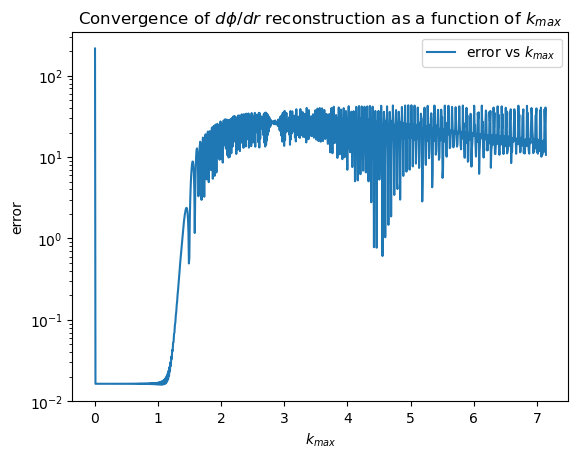

Minimum error of 1.61e-02 at n = 147, k_max = 1.05


In [10]:


plt.plot(kln_nodes_by_ell[0, :len(error)], error, label=r'error vs $k_{max}$')
plt.xlabel(r'$k_{max}$')
plt.ylabel('error')
plt.yscale('log')
plt.title(r'Convergence of $d\phi/dr$ reconstruction as a function of $k_{max}$')
plt.legend()
plt.show()

min_ind = np.argmin(error)
print(f'Minimum error of {error[min_ind]:.2e} at n = {min_ind + 1}, k_max = {kln_nodes_by_ell[0, min_ind]:.2f}')

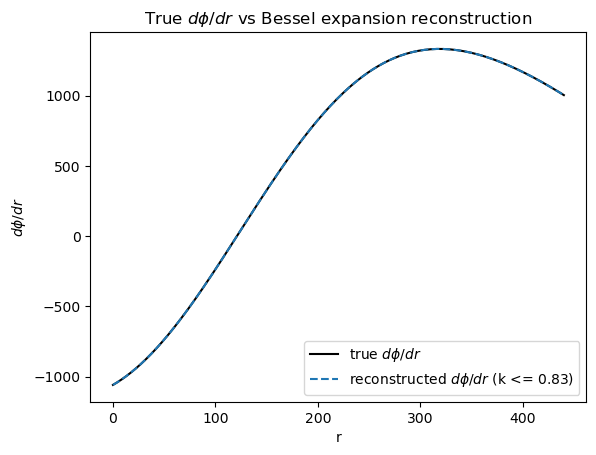

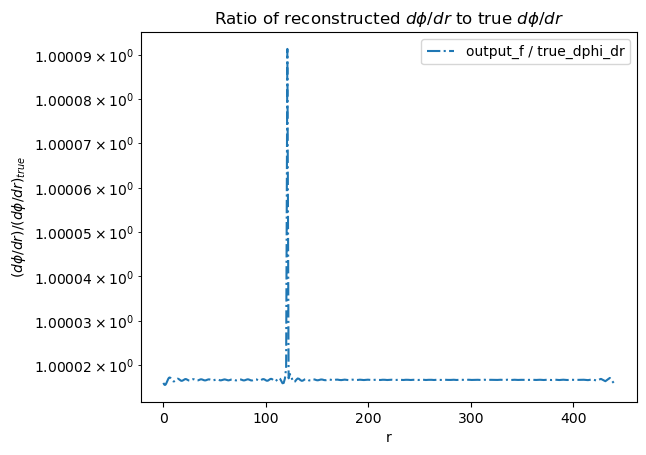

In [11]:
output_f = np.zeros_like(r_j)

for idx, (l_val, m_val) in enumerate(lm_pairs):
    for n in range(normalised.shape[1]):
        k_ln = kln_nodes_by_ell[l_val, n]
        dphi_coeff = -4 * np.pi * G * normalised[idx, n] / k_ln
        dj = spherical_jn(l_val, k_ln * r_j, derivative=True)
        if k_ln <= 0.83:
            output_f += dphi_coeff * dj
        


plt.plot(r_j, true_dphi_dr, label=r'true $d\phi/dr$', color='black')
plt.plot(r_j, output_f, label=r'reconstructed $d\phi/dr$ (k <= 0.83)', linestyle='--')
plt.xlabel('r')
plt.ylabel(r'$d\phi/dr$')
plt.title(r'True $d\phi/dr$ vs Bessel expansion reconstruction')
plt.legend()
plt.show()

plt.plot(r_j, output_f / true_dphi_dr, label='output_f / true_dphi_dr', linestyle='-.')
plt.xlabel('r')
plt.ylabel(r'$(d\phi/dr) / (d\phi/dr)_{true}$')
plt.yscale('log')
plt.title(r'Ratio of reconstructed $d\phi/dr$ to true $d\phi/dr$')
plt.legend()
plt.show()  

# Testing on a highly oscillatory function

## Nyquist theorem - Sampling rate must be at least twice the oscillation frequency

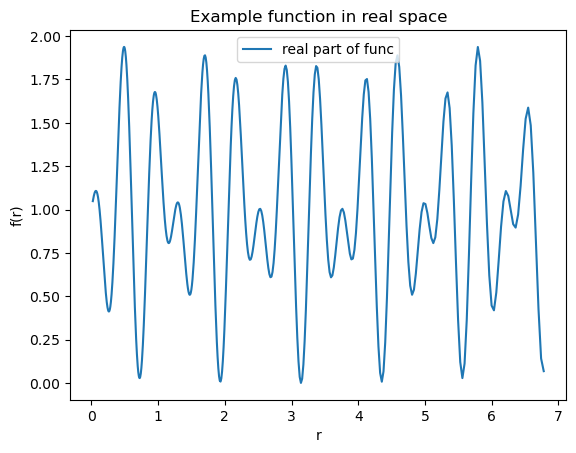

0.06807883787753743


In [12]:
import sys
sys.path.append('/home/joshua/PhD_year_1/jaxsp/Adding_stellar_masses')

from scipy.special import spherical_jn

import Boris_SBT_code as BSBT

import numpy as np

import jax

import matplotlib.pyplot as plt




rmin = 0.02
rmax = 6.78
no_radius_bins = 1000

r = np.logspace(np.log10(rmin), np.log10(rmax), no_radius_bins)

omega = 13

func = (np.exp(1j * omega * r)).real * np.sin(5/2*r) + 1


# TRYING FOR cNFWt FUNCTION ----------------------------------------------

# eps = 1
# rho_c_nfw_t = 1 / ((r + eps) * (1 + r)**2)


# func = rho_c_nfw_t


plt.plot(r, func, label='real part of func')
plt.xlabel('r')
plt.ylabel('f(r)')
#plt.xscale('log')
#plt.yscale('log')
plt.title('Example function in real space')
plt.legend()
plt.show()

print(func[-1])

In [13]:
l = [0]
L = max(l) + 1

Nmax = 1000


k_list = []
cln_list = []
for ell in range(L):
    k_nodes, _cln = BSBT.constructGridAndNorms(rmax, Nmax, ell)
    k_list.append(np.asarray(k_nodes, dtype=np.float64)) 
    cln_list.append(np.asarray(_cln, dtype=np.float64))

# For each value of ell, computes n k nodes and n cl normalization constants.

kln_nodes_by_ell = np.asarray(np.stack(k_list, axis=0)) 
cln_norms_by_ell = np.asarray(np.stack(cln_list, axis=0))  

print("kln_nodes_by_ell shape:", kln_nodes_by_ell.shape)
print("cln_norms_by_ell shape:", cln_norms_by_ell.shape) #(ell, n)


print(kln_nodes_by_ell)


kln_nodes_by_ell shape: (1, 1000)
cln_norms_by_ell shape: (1, 1000)
[[  0.46336175   0.9267235    1.39008524   1.85344699   2.31680874
    2.78017049   3.24353224   3.70689399   4.17025573   4.63361748
    5.09697923   5.56034098   6.02370273   6.48706448   6.95042622
    7.41378797   7.87714972   8.34051147   8.80387322   9.26723497
    9.73059671  10.19395846  10.65732021  11.12068196  11.58404371
   12.04740546  12.5107672   12.97412895  13.4374907   13.90085245
   14.3642142   14.82757595  15.29093769  15.75429944  16.21766119
   16.68102294  17.14438469  17.60774644  18.07110818  18.53446993
   18.99783168  19.46119343  19.92455518  20.38791693  20.85127867
   21.31464042  21.77800217  22.24136392  22.70472567  23.16808742
   23.63144916  24.09481091  24.55817266  25.02153441  25.48489616
   25.94825791  26.41161965  26.8749814   27.33834315  27.8017049
   28.26506665  28.7284284   29.19179014  29.65515189  30.11851364
   30.58187539  31.04523714  31.50859889  31.97196063  32.4353

In [14]:

import jax.numpy as jnp

r_j = jnp.logspace(np.log10(rmin), np.log10(rmax), no_radius_bins)

lm_pairs = [(0, 0)]
lm_l = np.array([0])
lm_m = np.array([0])

import importlib
importlib.reload(BSBT)

f_l_kln_all = BSBT.forward_dsbt_function(
    f_r = func,             # (Nr,) — function evaluated on r grid
    r = r_j,               # (Nr,)
    ell = 0,
    kln_nodes = kln_nodes_by_ell[0, :],
)


In [15]:
print(f_l_kln_all.shape) # (lm_pairs, n)

(1000,)


In [16]:
cln_for_lm = cln_norms_by_ell[lm_l, :]

normalised = f_l_kln_all * cln_for_lm

print(normalised)

[[ 2.00261449e+00 -2.01016860e+00  2.02374721e+00 -2.04140045e+00
   2.06772897e+00 -2.09614725e+00  2.13839754e+00 -2.17908056e+00
   2.24272540e+00 -2.29831002e+00  2.39303381e+00 -2.46794158e+00
   2.61205029e+00 -2.71387938e+00  2.94596288e+00 -3.08876203e+00
   3.50553887e+00 -3.71845277e+00  4.64667071e+00 -4.98913317e+00
   8.57596206e+00 -5.24685852e+00 -1.06064173e+01  8.12894296e+00
  -1.33082349e+00  5.99318128e-01  9.13700316e-01 -1.71528423e+00
   2.60085676e+00 -4.35211050e+00  5.46929247e+00 -1.35976663e+01
   1.44018616e+01  9.79123489e+00 -1.28789309e+01  5.71927358e+00
  -5.19813102e+00  3.45376430e+00 -3.22441695e+00  2.44051498e+00
  -2.30886529e+00  1.86299550e+00 -1.77619013e+00  1.48831018e+00
  -1.42632327e+00  1.22506754e+00 -1.17851530e+00  1.02991314e+00
  -9.93738949e-01  8.79538675e-01 -8.50739853e-01  7.60249886e-01
  -7.36913106e-01  6.63450155e-01 -6.44289745e-01  5.83459013e-01
  -5.67574715e-01  5.16366389e-01 -5.03106815e-01  4.59389685e-01
  -4.48270

Text(0, 0.5, '|coefficient|')

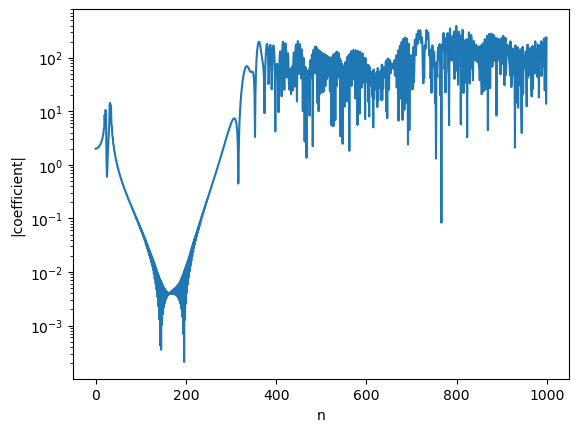

In [17]:

plt.semilogy(np.abs(normalised[0, :]))
plt.xlabel('n')
plt.ylabel('|coefficient|')


### $k_{l,n} = \frac{\alpha_{l,n}}{R}$. This means at n max, highest frequency oscillating  

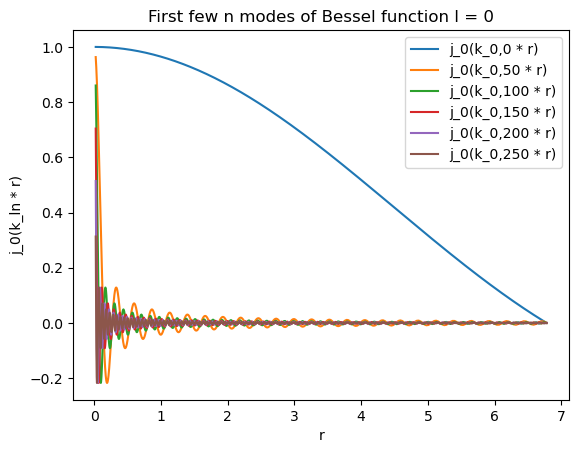

In [18]:
for i in range(0, 300, 50):
    plt.plot(r, spherical_jn(0, kln_nodes_by_ell[0, i] * r), label=f'j_0(k_0,{i} * r)')

plt.xlabel('r')
plt.ylabel('j_0(k_ln * r)')
plt.title('First few n modes of Bessel function l = 0')
plt.legend()
plt.show()


## Convergence as a function of k max

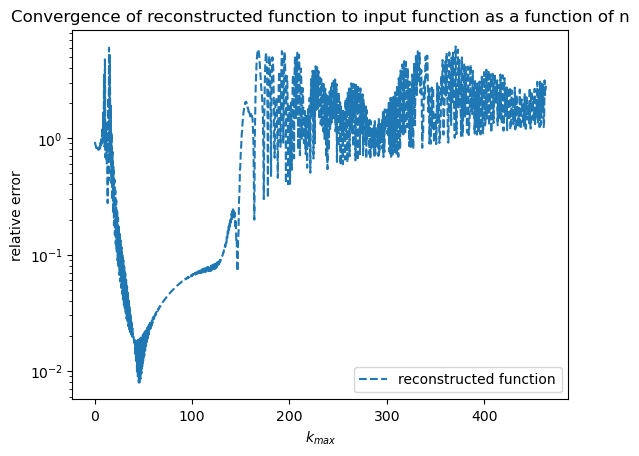

Minimum error at k_max = 45.40945133507376 with relative error = 0.007968996562898893


In [19]:
output_f = np.zeros_like(r_j)

Nmax  = 1000

per_n_contrib = np.zeros((Nmax, len(r_j)))

for n in range(Nmax):
    k_ln = kln_nodes_by_ell[0, n]
    coeff = normalised[0, n]
    per_n_contrib[n, :] = coeff * spherical_jn(0, k_ln * r_j)

cumsum = np.cumsum(per_n_contrib, axis=0)

error = np.sqrt(np.mean((cumsum - func)**2, axis=1)) / np.sqrt(np.mean(func**2))



plt.plot(kln_nodes_by_ell[0, :Nmax], error, label='reconstructed function', linestyle='--')
plt.xlabel(r'$k_{max}$')
plt.ylabel('relative error')
plt.yscale('log')
plt.title('Convergence of reconstructed function to input function as a function of n')
plt.legend()
plt.show()

min_ind = np.argmin(error)
min_error_k_max = kln_nodes_by_ell[0, min_ind]

print("Minimum error at k_max =", min_error_k_max, "with relative error =", error[min_ind])



r_diff: 0.00011697740352959243
1000
97


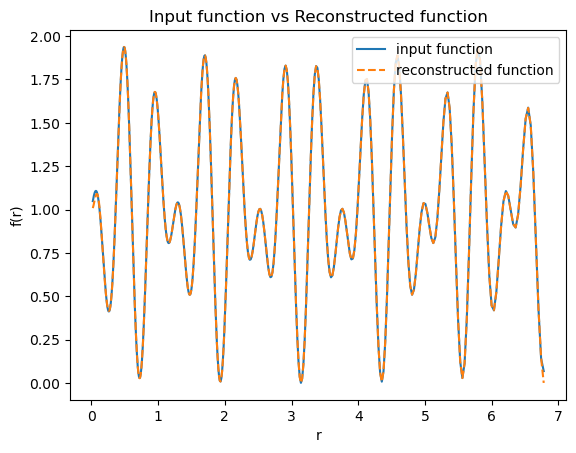

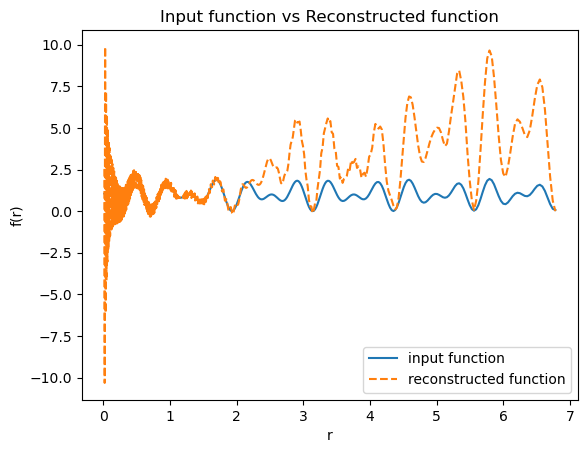

In [20]:
output_f = np.zeros_like(r_j)

Nmax = 1000

r_diff = r[1] - r[0]
print("r_diff:", r_diff)

print(len(kln_nodes_by_ell[0, :]))
mask = kln_nodes_by_ell[0, :] <= 45.4
print(np.sum(mask))

for n in range(Nmax):
    k_ln = kln_nodes_by_ell[0, n]
    if k_ln <= 45.4:
        coeff = normalised[0, n]
        output_f += coeff * spherical_jn(0, k_ln * r_j)

plt.plot(r_j, func, label='input function')
plt.plot(r_j, output_f, label='reconstructed function', linestyle='--')
plt.xlabel('r')
#plt.xscale('log')
#plt.yscale('log')
plt.ylabel('f(r)')
plt.title('Input function vs Reconstructed function')
plt.legend()
plt.show()

output_f = np.zeros_like(r_j)



for n in range(Nmax):
    k_ln = kln_nodes_by_ell[0, n]
    coeff = normalised[0, n]
    output_f += coeff * spherical_jn(0, k_ln * r_j)


plt.plot(r_j, func, label='input function')
plt.plot(r_j, output_f, label='reconstructed function', linestyle='--')
plt.xlabel('r')
plt.ylabel('f(r)')
#plt.xscale('log')
#plt.yscale('log')
plt.title('Input function vs Reconstructed function')
plt.legend()
plt.show()

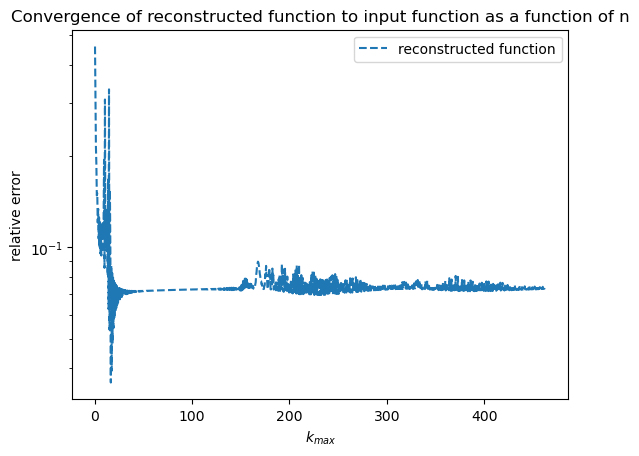

Minimum error at k_max = 16.68102293941483 with relative error = 0.03581506497814361


In [21]:
G = 1

true_dphi_dr = 4 * np.pi * G / r**2 / 275894451 * (
    1148364 * r * np.sin(31*r/2) +
    (74088-8899821*r**2) * np.cos(31*r/2) -
    250244*r*np.sin(21*r/2) +
    (13137831*r**2 - 238328) * np.cos(21*r/2) + 
    91964817 * r ** 3 + 164240
)

# true_dphi_dr = 4 * np.pi * G /r**2 * (np.log(1 + r) + 2 / (1 + r) - 1/(2*(r + 1)**2) -
#                 np.log(1.02) - 2/1.02 + 1/(2*1.02**2))

output_f = np.zeros_like(r_j)

Nmax  = 1000

per_n_contrib = np.zeros((Nmax, len(r_j)))

for n in range(Nmax):
    k_ln = kln_nodes_by_ell[0, n]
    coeff = -4 * np.pi * G * normalised[0, n] / k_ln
    per_n_contrib[n, :] = coeff * spherical_jn(0, k_ln * r_j, derivative=True)

cumsum = np.cumsum(per_n_contrib, axis=0)

error = np.sqrt(np.mean((cumsum - true_dphi_dr)**2, axis=1)) / np.sqrt(np.mean(true_dphi_dr**2))



plt.plot(kln_nodes_by_ell[0, :Nmax], error, label='reconstructed function', linestyle='--')
plt.xlabel(r'$k_{max}$')
plt.ylabel('relative error')
plt.yscale('log')
plt.title('Convergence of reconstructed function to input function as a function of n')
plt.legend()
plt.show()

min_ind = np.argmin(error)
min_error_k_max = kln_nodes_by_ell[0, min_ind]

print("Minimum error at k_max =", min_error_k_max, "with relative error =", error[min_ind])




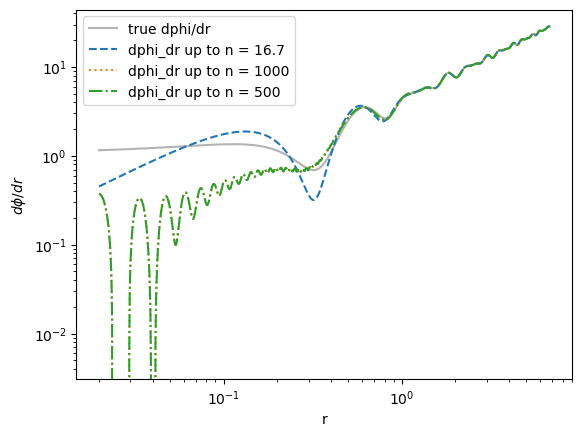

In [22]:
plt.plot(r, true_dphi_dr, label='true dphi/dr', color='black', alpha = 0.3)


output_f = np.zeros_like(r_j)
output_f_above = np.zeros_like(r_j)
output_f_below = np.zeros_like(r_j)

Nmax = 1000

mask = 16.7

for n in range(Nmax):
    k_ln = kln_nodes_by_ell[0, n]
    if k_ln <= mask:
        coeff = -4 * np.pi * G * normalised[0, n] / k_ln
        output_f += coeff * spherical_jn(0, k_ln * r_j, derivative = True)
    
    if k_ln <= 500:
        coeff = -4 * np.pi * G * normalised[0, n] / k_ln
        output_f_below += coeff * spherical_jn(0, k_ln * r_j, derivative = True)
        
    coeff = -4 * np.pi * G * normalised[0, n] / k_ln
    output_f_above += coeff * spherical_jn(0, k_ln * r_j, derivative = True)


plt.plot(r, output_f, label=f'dphi_dr up to n = {mask}', linestyle='--')
plt.plot(r, output_f_above, label=f'dphi_dr up to n = {1000}', linestyle=':')
plt.plot(r, output_f_below, label=f'dphi_dr up to n = {500}', linestyle='-.')
plt.xlabel('r')
plt.yscale('log')
plt.xscale('log')
plt.ylabel(r'$d\phi/dr$')
plt.legend()
plt.show()

# After meeting with Boris, found that need to pick N first which then decides r grid

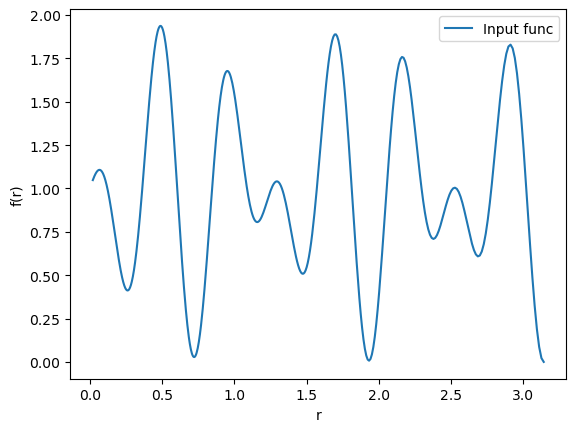

In [23]:
rmin = 0.02
rmax = np.pi
no_radius_bins = 1000

r = np.logspace(np.log10(rmin), np.log10(rmax), no_radius_bins)

omega = 13

func = (np.exp(1j * omega * r)).real * np.sin(5/2*r) + 1

plt.plot(r, func, label='Input func')
plt.xlabel('r')
plt.ylabel('f(r)')
plt.legend()
plt.show()


### Quicker oscillation coming from omega = 13 therefore need to resolve scales of $r = \frac{\pi}{2 * 13}$
### Therefore, $N_{max} \simeq \frac{r_{max}}{\delta r} = \frac{\pi}{\pi/26} = 26$
### Our r-grid should now be $r_n = \frac{z_{l,n}}{z_{l,N+1}} * r_{max}$

In [24]:
l = [0]
L = max(l) + 1

Nmax = 1000


k_list = []
cln_list = []
for ell in range(L):
    k_nodes, _cln = BSBT.constructGridAndNorms(rmax, Nmax, ell)
    k_list.append(np.asarray(k_nodes, dtype=np.float64)) 
    cln_list.append(np.asarray(_cln, dtype=np.float64))

# For each value of ell, computes n k nodes and n cl normalization constants.

kln_nodes_by_ell = np.asarray(np.stack(k_list, axis=0)) 
cln_norms_by_ell = np.asarray(np.stack(cln_list, axis=0))  

print("kln_nodes_by_ell shape:", kln_nodes_by_ell.shape)
print("cln_norms_by_ell shape:", cln_norms_by_ell.shape) #(ell, n)


print(kln_nodes_by_ell)

Z_0 = BSBT.rootsSphericalBesselFunctions(L, Nmax + 1)[0]

Z_0_N = Z_0[-1]

Z_0 = Z_0[:Nmax]

print("Z_0:", Z_0)
print("Z_0_N:", Z_0_N)

r_grid = Z_0 / Z_0_N * rmax
print("r_grid:", r_grid)

kln_nodes_by_ell shape: (1, 1000)
cln_norms_by_ell shape: (1, 1000)
[[   1.    2.    3.    4.    5.    6.    7.    8.    9.   10.   11.   12.
    13.   14.   15.   16.   17.   18.   19.   20.   21.   22.   23.   24.
    25.   26.   27.   28.   29.   30.   31.   32.   33.   34.   35.   36.
    37.   38.   39.   40.   41.   42.   43.   44.   45.   46.   47.   48.
    49.   50.   51.   52.   53.   54.   55.   56.   57.   58.   59.   60.
    61.   62.   63.   64.   65.   66.   67.   68.   69.   70.   71.   72.
    73.   74.   75.   76.   77.   78.   79.   80.   81.   82.   83.   84.
    85.   86.   87.   88.   89.   90.   91.   92.   93.   94.   95.   96.
    97.   98.   99.  100.  101.  102.  103.  104.  105.  106.  107.  108.
   109.  110.  111.  112.  113.  114.  115.  116.  117.  118.  119.  120.
   121.  122.  123.  124.  125.  126.  127.  128.  129.  130.  131.  132.
   133.  134.  135.  136.  137.  138.  139.  140.  141.  142.  143.  144.
   145.  146.  147.  148.  149.  150.  151. 

In [25]:

lm_pairs = [(0, 0)]
lm_l = np.array([0])
lm_m = np.array([0])

func = (np.exp(1j * omega * r_grid)).real * np.sin(5/2*r_grid) + 1

f_l_kln_all = BSBT.forward_dsbt_function(
    f_r = func,             # (Nr,) — function evaluated on r grid
    r = r_grid,               # (Nr,)
    ell = 0,
    kln_nodes = kln_nodes_by_ell[0, :],
)

[[ 2.01372069e+00 -2.05291697e+00  2.13201537e+00 -2.23220978e+00
   2.42706868e+00 -2.62596877e+00  3.13029691e+00 -3.56723615e+00
   5.87919981e+00 -6.15686523e+00 -1.32607251e+00  1.46223490e+00
   1.49413174e+00 -4.95322230e+00  5.36080083e+00  5.90760507e+00
  -6.68447511e+00  2.97603477e+00 -2.63526845e+00  1.76159590e+00
  -1.61113566e+00  1.22340059e+00 -1.13776916e+00  9.19605818e-01
  -8.64518686e-01  7.25208601e-01 -6.87140851e-01  5.90853540e-01
  -5.63271244e-01  4.92995425e-01 -4.72321306e-01  4.18942584e-01
  -4.03044862e-01  3.61241740e-01 -3.48769614e-01  3.15228503e-01
  -3.05285132e-01  2.77836681e-01 -2.69804286e-01  2.46970029e-01
  -2.40410153e-01  2.21148710e-01 -2.15742356e-01  1.99299722e-01
  -1.94809898e-01  1.80627216e-01 -1.76874664e-01  1.64529293e-01
  -1.61376304e-01  1.50542972e-01 -1.47882300e-01  1.38306791e-01
  -1.36053902e-01  1.27534806e-01 -1.25622353e-01  1.17998144e-01
  -1.16371949e-01  1.09511663e-01 -1.08127770e-01  1.01924166e-01
  -1.00746

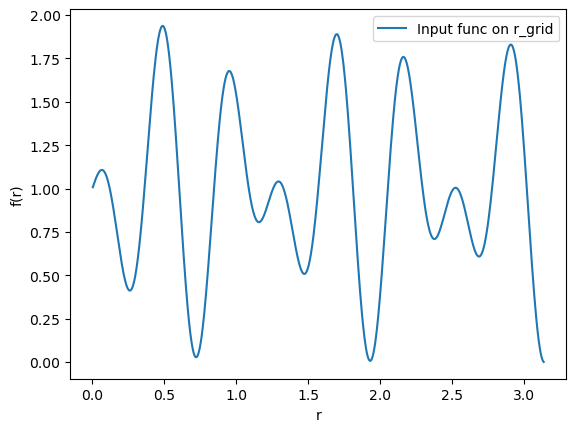

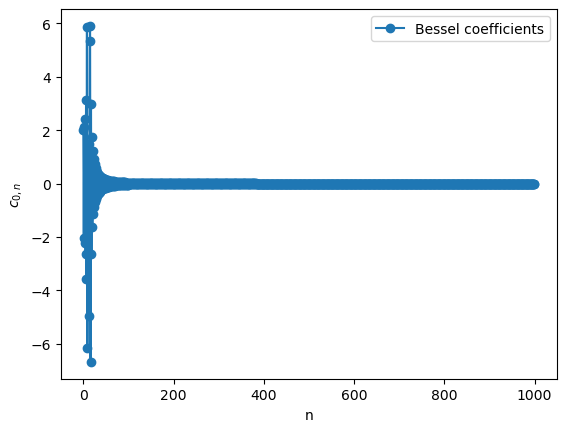

In [26]:
cln_for_lm = cln_norms_by_ell[lm_l, :]

normalised = f_l_kln_all * cln_for_lm

print(normalised)

plt.plot(r_grid, func, label='Input func on r_grid')
plt.xlabel('r')
plt.ylabel('f(r)')
plt.legend()
plt.show()

plt.plot(np.arange(Nmax), normalised[0, :], marker='o', label='Bessel coefficients')
plt.xlabel('n')
plt.ylabel(r'$c_{0,n}$')
plt.legend()
plt.show()

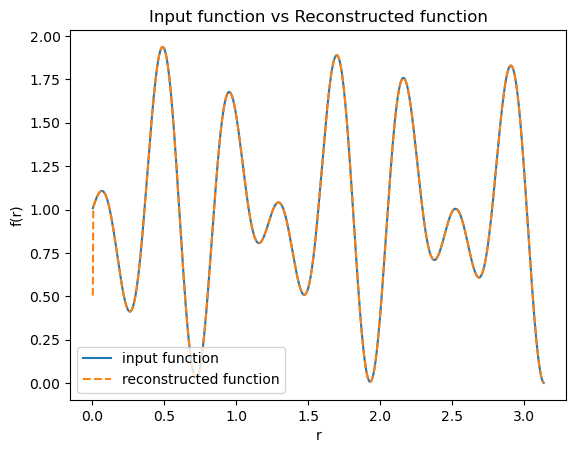

In [27]:

output_f = np.zeros_like(r_grid)

for n in range(Nmax):
    k_ln = kln_nodes_by_ell[0, n]
    coeff = normalised[0, n]
    output_f += coeff * spherical_jn(0, k_ln * r_grid)


plt.plot(r_grid, func, label='input function')
plt.plot(r_grid, output_f, label='reconstructed function', linestyle='--')
plt.xlabel('r')
plt.ylabel('f(r)')
#plt.xscale('log')
#plt.yscale('log')
plt.title('Input function vs Reconstructed function')
plt.legend()
plt.show()

# Try now with linear sum of bessel functions
### 1) Input $f(r) = j_0(k_{0,0}*r) + 2j_0(k_{0,1}*r) + j_0(k_{0,4}*r) $
### answer should be $a_{0,0} = 1, a_{0,1} = 2, a_{0,4} = 1, a_{l,n}$ for the rest
### Try to only reproduce near the particle (around 0.19)

kln_nodes_by_ell shape: (1, 1500)
cln_norms_by_ell shape: (1, 1500)
r_grid: [1.33244504e-02 2.66489007e-02 3.99733511e-02 ... 1.99600266e+01
 1.99733511e+01 1.99866755e+01]
kln_nodes_by_ell shape: (1, 1500)
cln_norms_by_ell shape: (1, 1500)


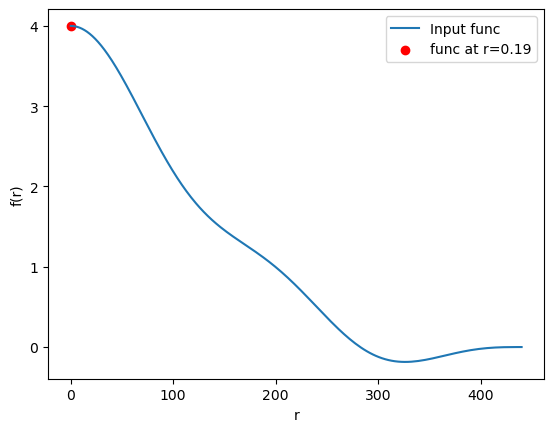

func at r = 0.19 is 3.999989571340505


In [28]:
rmin = 0.02
rmax = 440

no_radius_bins = 1000

r = np.logspace(np.log10(rmin), np.log10(rmax), no_radius_bins)


l = [0]
L = max(l) + 1

Nmax = 1500

r_max_inner = 20

k_list = []
cln_list = []
for ell in range(L):
    k_nodes, _cln = BSBT.constructGridAndNorms(r_max_inner, Nmax, ell)
    k_list.append(np.asarray(k_nodes, dtype=np.float64)) 
    cln_list.append(np.asarray(_cln, dtype=np.float64))

# For each value of ell, computes n k nodes and n cl normalization constants.

kln_nodes_by_ell_inner = np.asarray(np.stack(k_list, axis=0)) 
cln_norms_by_ell_inner = np.asarray(np.stack(cln_list, axis=0))  

print("kln_nodes_by_ell shape:", kln_nodes_by_ell_inner.shape)
print("cln_norms_by_ell shape:", cln_norms_by_ell_inner.shape) #(ell, n)


Z_0 = BSBT.rootsSphericalBesselFunctions(L, Nmax + 1)[0]

Z_0_N = Z_0[-1]

Z_0 = Z_0[:Nmax]

r_grid = Z_0 / Z_0_N * r_max_inner
print("r_grid:", r_grid)



k_list = []
cln_list = []
for ell in range(L):
    k_nodes, _cln = BSBT.constructGridAndNorms(rmax, Nmax, ell)
    k_list.append(np.asarray(k_nodes, dtype=np.float64)) 
    cln_list.append(np.asarray(_cln, dtype=np.float64))

# For each value of ell, computes n k nodes and n cl normalization constants.

kln_nodes_by_ell = np.asarray(np.stack(k_list, axis=0)) 
cln_norms_by_ell = np.asarray(np.stack(cln_list, axis=0))  

print("kln_nodes_by_ell shape:", kln_nodes_by_ell.shape)
print("cln_norms_by_ell shape:", cln_norms_by_ell.shape) #(ell, n)

full_r_grid = Z_0 / Z_0_N * rmax

func_on_full_r_grid = (spherical_jn(0, kln_nodes_by_ell[0, 0] * full_r_grid) + 2 * spherical_jn(0, kln_nodes_by_ell[0, 1] * full_r_grid) + spherical_jn(0, kln_nodes_by_ell[0, 4] * full_r_grid))


full_func = (spherical_jn(0, kln_nodes_by_ell[0, 0] * r) + 2 * spherical_jn(0, kln_nodes_by_ell[0, 1] * r) + spherical_jn(0, kln_nodes_by_ell[0, 4] * r))


r_part = 0.19
func_at_part = (spherical_jn(0, kln_nodes_by_ell[0, 0] * r_part) + 2 * spherical_jn(0, kln_nodes_by_ell[0, 1] * r_part) + spherical_jn(0, kln_nodes_by_ell[0, 4] * r_part))

plt.plot(r, full_func, label='Input func')
plt.scatter(r_part, func_at_part, color='red', label=f'func at r={r_part}')
plt.xlabel('r')
plt.ylabel('f(r)')
plt.legend()
plt.show()

print("func at r =", r_part, "is", func_at_part)

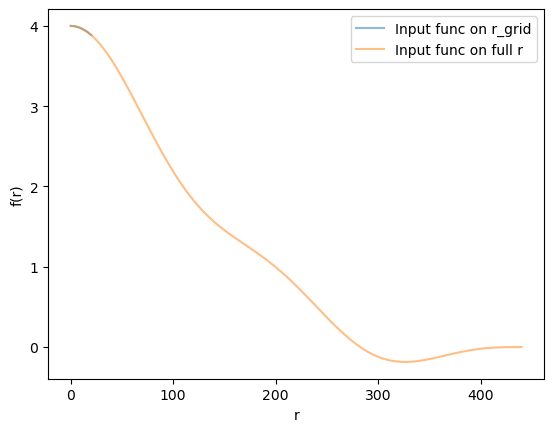

7.910300034775197
-7.806518509260259
7.778171907285249
[[ 7.91030003 -7.80651851  7.78789519 ...  0.03815687 -0.02552512
   0.01273612]]


In [29]:

lm_pairs = np.array([(0, 0)])
lm_l = lm_pairs[:, 0]
lm_m = lm_pairs[:, 1]

func_inner = (spherical_jn(0, kln_nodes_by_ell[0, 0] * r_grid) + 2 * spherical_jn(0, kln_nodes_by_ell[0, 1] * r_grid) + spherical_jn(0, kln_nodes_by_ell[0, 4] * r_grid))


plt.plot(r_grid, func_inner, label='Input func on r_grid', alpha = 0.5)
plt.plot(r, full_func, label='Input func on full r', alpha = 0.5)
plt.xlabel('r')
plt.ylabel('f(r)')
plt.legend()
plt.show()

f_l_kln_all = BSBT.forward_dsbt_function(
    f_r = func_inner,             # (Nr,) — function evaluated on r grid
    r = r_grid,            # (Nr)
    ell = 0,
    kln_nodes = kln_nodes_by_ell_inner[0, :],
)

normalised = f_l_kln_all * cln_norms_by_ell_inner[lm_l, :]

print(normalised[0, 0])
print(normalised[0, 1])
print(normalised[0, 4])

# should be 1, 2, 1

print(normalised)

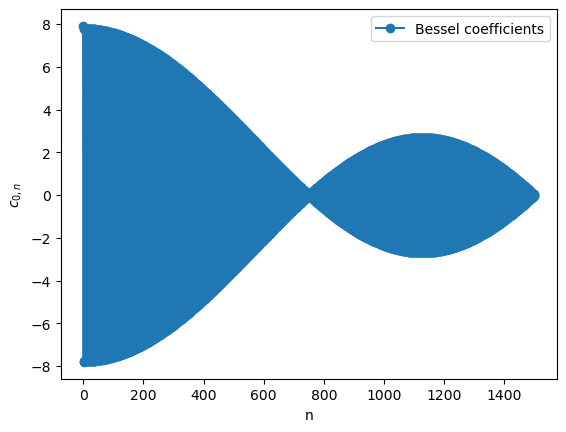

In [30]:


plt.plot(np.arange(Nmax), normalised[0, :], marker='o', label='Bessel coefficients')
plt.xlabel('n')
plt.ylabel(r'$c_{0,n}$')
plt.legend()
plt.show()

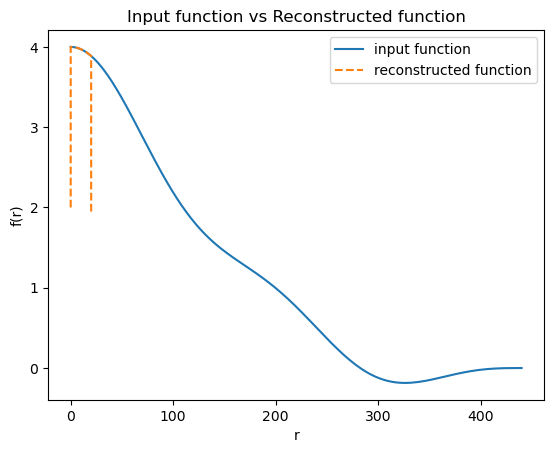

[1.99999997 3.99999979 3.99999954 ... 3.88714414 3.88699637 1.94342426]
[1.33244504e-02 2.66489007e-02 3.99733511e-02 ... 1.99600266e+01
 1.99733511e+01 1.99866755e+01]
reconstructed func at r = 0.19 is 4.000362670302547


In [31]:

output_f = np.zeros_like(r_grid)

for n in range(Nmax):
    k_ln = kln_nodes_by_ell_inner[0, n]
    coeff = normalised[0, n]
    output_f += coeff * spherical_jn(0, k_ln * r_grid)




plt.plot(r, full_func, label='input function')
plt.plot(r_grid, output_f, label='reconstructed function', linestyle='--')
plt.xlabel('r')
plt.ylabel('f(r)')
#plt.xscale('log')
#plt.yscale('log')
plt.title('Input function vs Reconstructed function')
plt.legend()
plt.show()

print(output_f)
print(r_grid)

r_part = 0.19
output_f_at_part = 0
for n in range(Nmax):
    k_ln = kln_nodes_by_ell_inner[0, n]
    coeff = normalised[0, n]
    output_f_at_part += coeff * spherical_jn(0, k_ln * r_part)
print("reconstructed func at r =", r_part, "is", output_f_at_part)

### Getting phi

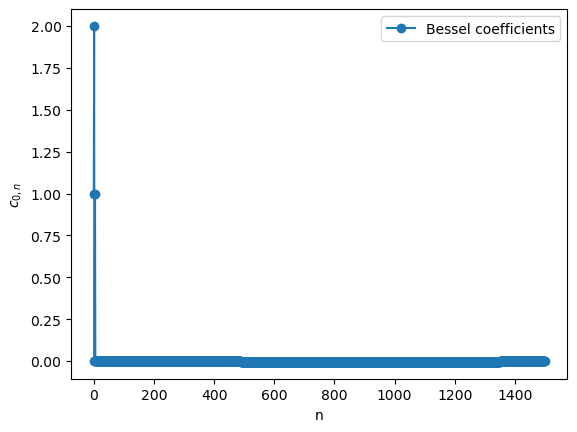

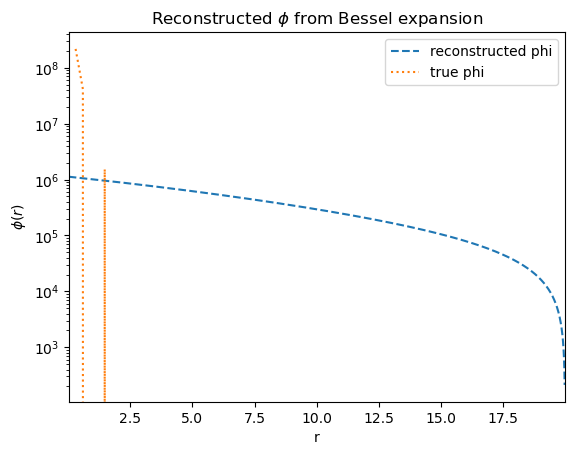

[-2.17985194e+08 -4.16934257e+07  7.66079756e-01 ...  5.76863669e-09
  2.56211806e-09  6.39255455e-10]


In [32]:
phi_ln = -4 * np.pi * G * output_f / kln_nodes_by_ell[0, :Nmax]**2

phi_recon = np.zeros_like(r_grid)
for n in range(Nmax):
    k_ln = kln_nodes_by_ell_inner[0, n]
    coeff = phi_ln[n]
    phi_recon += coeff * spherical_jn(0, k_ln * r_grid)

f_l_kln_all = BSBT.forward_dsbt_function(
    f_r = func_on_full_r_grid,             # (Nr,) — function evaluated on r grid
    r = full_r_grid,            # (Nr)
    ell = 0,
    kln_nodes = kln_nodes_by_ell[0, :],
)

full_normalised = f_l_kln_all * cln_norms_by_ell[lm_l, :]


plt.plot(np.arange(Nmax), full_normalised[0, :], marker='o', label='Bessel coefficients')
plt.xlabel('n')
plt.ylabel(r'$c_{0,n}$')
plt.legend()
plt.show()

phi_lm_true = -4 * np.pi * G * full_normalised / kln_nodes_by_ell[0, :Nmax]**2

phi_true = np.zeros_like(full_r_grid)
for n in range(Nmax):
    k_ln = kln_nodes_by_ell[0, n]
    coeff = phi_lm_true[n]
    phi_true += coeff * spherical_jn(0, k_ln * full_r_grid)



plt.plot(r_grid, -phi_recon, label='reconstructed phi', linestyle='--')
plt.plot(full_r_grid, -phi_true, label='true phi', linestyle=':')
plt.xlabel('r')
plt.ylabel(r'$\phi(r)$')
plt.title(r'Reconstructed $\phi$ from Bessel expansion')
plt.xlim([r_grid[0], r_grid[-1]])
plt.yscale('log')
#plt.xscale('log')
plt.legend()
plt.show()

print(phi_true)

[[ 3.38966193e-01  1.19648075e+00  2.16691800e+00 ... -5.32851253e+02
  -5.43213607e+02 -4.02914440e+02]]


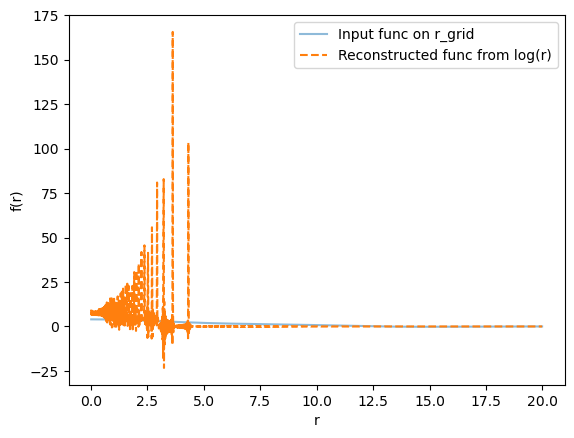

In [34]:
# Using change of variables to log(r)

r_log = np.log(r_grid)

def func_log_r(log_r):
    r = np.exp(log_r)
    return (spherical_jn(0, kln_nodes_by_ell[0, 0] * r) + 2 * spherical_jn(0, kln_nodes_by_ell[0, 1] * r) + spherical_jn(0, kln_nodes_by_ell[0, 4] * r))

f_l_kln_all_log = BSBT.forward_dsbt_function(
    f_r = func_log_r(r_log),             # (Nr,) — function evaluated on
    r = r_log,            # (Nr)
    ell = 0,
    kln_nodes = kln_nodes_by_ell_inner[0, :],
)
normalised_log = f_l_kln_all_log * cln_norms_by_ell_inner[lm_l, :]
print(normalised_log)

output_f_log = np.zeros_like(r_log)
for n in range(Nmax):
    k_ln = kln_nodes_by_ell_inner[0, n]
    coeff = normalised_log[0, n]
    output_f_log += coeff * spherical_jn(0, k_ln * r_grid)

plt.plot(r_grid, func_on_full_r_grid, label='Input func on r_grid', alpha = 0.5)
plt.plot(r_grid, output_f_log, label='Reconstructed func from log(r)', linestyle='--')
plt.xlabel('r')
plt.ylabel('f(r)')
plt.legend()
plt.show()

